In [17]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set up directories
results_dir = Path('../results')
data_dir = Path('../data')

print("📦 Libraries loaded successfully!")
print(f"📁 Results directory: {results_dir}")
print(f"📊 Available result files: {list(results_dir.glob('*.json'))}")


📦 Libraries loaded successfully!
📁 Results directory: ../results
📊 Available result files: [PosixPath('../results/tg_gcn_baseline_results.json'), PosixPath('../results/tg_fingerprint_baseline_cv_results.json'), PosixPath('../results/analysis_summary_20250719_111856.json'), PosixPath('../results/analysis_summary_20250719_111628.json'), PosixPath('../results/analysis_summary_20250719_103414.json'), PosixPath('../results/tg_fingerprint_baseline_results.json')]


In [18]:
def load_model_results(model_name='tg_fingerprint_baseline'):
    """Load all result files for a specific model."""
    results = {}
    
    # Load cross-validation results
    cv_file = results_dir / f"{model_name}_cv_results.json"
    if cv_file.exists():
        with open(cv_file, 'r') as f:
            results['cv'] = json.load(f)
    
    # Load training results
    train_file = results_dir / f"{model_name}_results.json"
    if train_file.exists():
        with open(train_file, 'r') as f:
            results['training'] = json.load(f)
    
    # Load training curves image path
    curves_file = results_dir / f"{model_name}_training_curves.png"
    if curves_file.exists():
        results['curves_path'] = str(curves_file)
    
    return results

def load_dataset_info():
    """Load dataset information for context."""
    processed_data_path = data_dir / 'processed' / 'filtered_tg_dataset.csv'
    if processed_data_path.exists():
        df = pd.read_csv(processed_data_path)
        return {
            'total_samples': len(df),
            'target_range': (df['Tg'].min(), df['Tg'].max()),
            'target_mean': df['Tg'].mean(),
            'target_std': df['Tg'].std()
        }
    return None

# Load current results
current_results = load_model_results()
dataset_info = load_dataset_info()

print("✅ Data loaded successfully!")
print(f"📈 Available data: {list(current_results.keys())}")
if dataset_info:
    print(f"🎯 Dataset: {dataset_info['total_samples']} samples, Tg range: {dataset_info['target_range'][0]:.1f} to {dataset_info['target_range'][1]:.1f}°C")


✅ Data loaded successfully!
📈 Available data: ['cv', 'training', 'curves_path']
🎯 Dataset: 510 samples, Tg range: -148.0 to 472.2°C


In [19]:
def create_performance_summary(results):
    """Create a comprehensive performance summary."""
    if 'cv' not in results:
        print("❌ No cross-validation results found")
        return
    
    cv = results['cv']
    
    # Performance metrics
    print("🎯 CROSS-VALIDATION PERFORMANCE SUMMARY")
    print("=" * 50)
    print(f"📈 R² Score:    {cv['mean_r2']:.4f} ± {cv['std_r2']:.4f}")
    print(f"📉 RMSE:        {cv['mean_rmse']:.2f} ± {cv['std_rmse']:.2f} °C")
    print(f"📊 MAE:         {cv['mean_mae']:.2f} ± {cv['std_mae']:.2f} °C")
    print()
    
    # Fold-wise performance
    print("📋 INDIVIDUAL FOLD PERFORMANCE")
    print("-" * 40)
    for i, (r2, rmse, mae) in enumerate(zip(cv['fold_scores']['r2'], 
                                            cv['fold_scores']['rmse'], 
                                            cv['fold_scores']['mae'])):
        print(f"Fold {i+1}: R²={r2:.4f}, RMSE={rmse:.2f}°C, MAE={mae:.2f}°C")
    
    print()
    
    # Performance interpretation
    r2 = cv['mean_r2']
    rmse = cv['mean_rmse']
    
    print("🔍 PERFORMANCE INTERPRETATION")
    print("-" * 35)
    
    if r2 >= 0.7:
        r2_grade = "Excellent 🌟"
    elif r2 >= 0.5:
        r2_grade = "Good 👍"
    elif r2 >= 0.3:
        r2_grade = "Fair 📈"
    else:
        r2_grade = "Needs Improvement ⚠️"
    
    print(f"Model Accuracy: {r2_grade}")
    print(f"Explains {r2*100:.1f}% of Tg variance")
    
    if dataset_info:
        target_std = dataset_info['target_std']
        relative_error = rmse / target_std
        print(f"RMSE is {relative_error:.2f}x the dataset standard deviation")
    
    return cv

performance_summary = create_performance_summary(current_results)


🎯 CROSS-VALIDATION PERFORMANCE SUMMARY
📈 R² Score:    0.4107 ± 0.0258
📉 RMSE:        84.14 ± 8.80 °C
📊 MAE:         63.78 ± 6.71 °C

📋 INDIVIDUAL FOLD PERFORMANCE
----------------------------------------
Fold 1: R²=0.4160, RMSE=98.87°C, MAE=74.98°C
Fold 2: R²=0.4143, RMSE=81.89°C, MAE=63.94°C
Fold 3: R²=0.4542, RMSE=87.06°C, MAE=63.84°C
Fold 4: R²=0.3865, RMSE=80.84°C, MAE=62.21°C
Fold 5: R²=0.3823, RMSE=72.06°C, MAE=53.93°C

🔍 PERFORMANCE INTERPRETATION
-----------------------------------
Model Accuracy: Fair 📈
Explains 41.1% of Tg variance
RMSE is 0.76x the dataset standard deviation


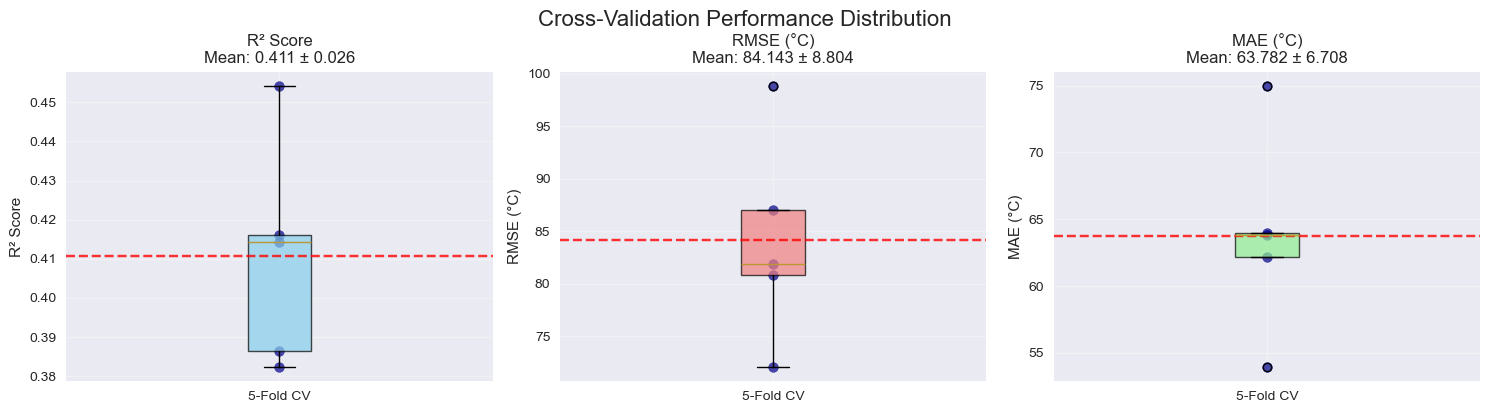

In [20]:
def plot_cv_performance_distribution(cv_results):
    """Plot distribution of cross-validation performance across folds."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    metrics = ['r2', 'rmse', 'mae']
    titles = ['R² Score', 'RMSE (°C)', 'MAE (°C)']
    colors = ['skyblue', 'lightcoral', 'lightgreen']
    
    for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        values = cv_results['fold_scores'][metric]
        mean_val = np.mean(values)
        std_val = np.std(values)
        
        # Box plot
        axes[i].boxplot(values, patch_artist=True, 
                       boxprops=dict(facecolor=color, alpha=0.7))
        
        # Add individual points
        axes[i].scatter([1]*len(values), values, 
                       alpha=0.7, s=50, color='darkblue')
        
        # Add mean line
        axes[i].axhline(y=mean_val, color='red', linestyle='--', alpha=0.8)
        
        axes[i].set_title(f'{title}\nMean: {mean_val:.3f} ± {std_val:.3f}')
        axes[i].set_ylabel(title)
        axes[i].set_xticks([1])
        axes[i].set_xticklabels(['5-Fold CV'])
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Cross-Validation Performance Distribution', y=1.02, fontsize=16)
    plt.show()

if performance_summary:
    plot_cv_performance_distribution(performance_summary)


🏆 MODEL PERFORMANCE LEADERBOARD
🥇 Tg Fingerprint Baseline
   📊 R²: 0.4107 ± 0.0258
   📉 RMSE: 84.14 ± 8.80 °C
   ⚡ Training Time: ~8 seconds (5-fold CV)
   🏗️ Architecture: Fingerprint + MLP
   📝 Notes: Initial baseline with robust cross-validation



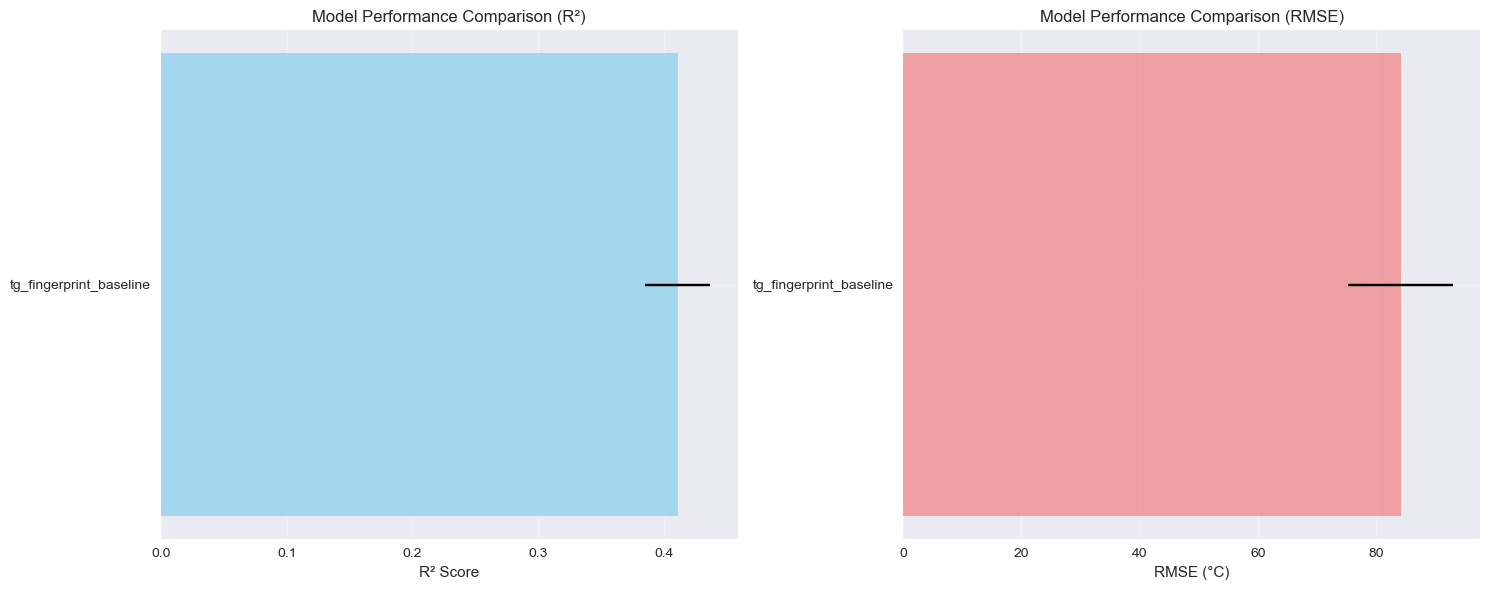

In [21]:
# Model Performance Tracking Database
# This will grow as you implement more models

MODEL_HISTORY = {
    'tg_fingerprint_baseline': {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'type': 'Fingerprint + MLP',
        'features': 'Morgan Fingerprints (2048-bit) + Polymer Chain Features (10)',
        'architecture': '3-layer MLP (512→256→128→1)',
        'r2_mean': current_results.get('cv', {}).get('mean_r2', 0),
        'r2_std': current_results.get('cv', {}).get('std_r2', 0),
        'rmse_mean': current_results.get('cv', {}).get('mean_rmse', 0),
        'rmse_std': current_results.get('cv', {}).get('std_rmse', 0),
        'mae_mean': current_results.get('cv', {}).get('mean_mae', 0),
        'mae_std': current_results.get('cv', {}).get('std_mae', 0),
        'training_time': '~8 seconds (5-fold CV)',
        'notes': 'Initial baseline with robust cross-validation'
    }
    # Add new models here as you implement them:
    # 'graph_conv_baseline': {...},
    # 'graph_attention_model': {...},
    # etc.
}

def create_model_comparison_dashboard():
    """Create a comprehensive comparison dashboard."""
    
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame.from_dict(MODEL_HISTORY, orient='index')
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'model'}, inplace=True)
    
    print("🏆 MODEL PERFORMANCE LEADERBOARD")
    print("=" * 50)
    
    # Sort by R² score
    df_sorted = df.sort_values('r2_mean', ascending=False)
    
    for idx, row in df_sorted.iterrows():
        print(f"🥇 {row['model'].replace('_', ' ').title()}")
        print(f"   📊 R²: {row['r2_mean']:.4f} ± {row['r2_std']:.4f}")
        print(f"   📉 RMSE: {row['rmse_mean']:.2f} ± {row['rmse_std']:.2f} °C")
        print(f"   ⚡ Training Time: {row['training_time']}")
        print(f"   🏗️ Architecture: {row['type']}")
        print(f"   📝 Notes: {row['notes']}")
        print()
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # R² comparison
    axes[0].barh(df['model'], df['r2_mean'], xerr=df['r2_std'], 
                alpha=0.7, color='skyblue', capsize=5)
    axes[0].set_xlabel('R² Score')
    axes[0].set_title('Model Performance Comparison (R²)')
    axes[0].grid(True, alpha=0.3)
    
    # RMSE comparison
    axes[1].barh(df['model'], df['rmse_mean'], xerr=df['rmse_std'], 
                alpha=0.7, color='lightcoral', capsize=5)
    axes[1].set_xlabel('RMSE (°C)')
    axes[1].set_title('Model Performance Comparison (RMSE)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df

comparison_df = create_model_comparison_dashboard()


In [22]:
def generate_model_insights(results, dataset_info):
    """Generate actionable insights about model performance."""
    
    if 'cv' not in results:
        return
    
    cv = results['cv']
    r2 = cv['mean_r2']
    rmse = cv['mean_rmse']
    mae = cv['mean_mae']
    
    print("🧠 MODEL INSIGHTS & DIAGNOSTICS")
    print("=" * 40)
    
    # Performance insights
    print("📈 PERFORMANCE ANALYSIS:")
    if r2 > 0.7:
        print("   ✨ Excellent predictive power - model captures most variance")
    elif r2 > 0.5:
        print("   👍 Good predictive power - decent chemical understanding")
    elif r2 > 0.3:
        print("   📊 Fair predictive power - captures some patterns")
        print("   💡 Suggestion: Try more complex architectures or features")
    else:
        print("   ⚠️ Low predictive power - needs significant improvement")
        print("   🔧 Suggestion: Revisit feature engineering and model architecture")
    
    print()
    
    # Error analysis
    print("🎯 ERROR ANALYSIS:")
    if dataset_info:
        target_std = dataset_info['target_std']
        target_range = dataset_info['target_range'][1] - dataset_info['target_range'][0]
        
        rmse_ratio = rmse / target_std
        mae_ratio = mae / target_range
        
        print(f"   📊 RMSE is {rmse_ratio:.2f}x the dataset standard deviation")
        print(f"   📏 MAE is {mae_ratio:.1%} of the target range")
        
        if rmse_ratio < 0.5:
            print("   ✅ Very good error relative to data variability")
        elif rmse_ratio < 1.0:
            print("   👍 Good error relative to data variability")
        else:
            print("   ⚠️ Error is high relative to data variability")
    
    print()
    
    # Model reliability
    print("🔒 MODEL RELIABILITY:")
    r2_cv = cv['std_r2'] / cv['mean_r2'] if cv['mean_r2'] > 0 else float('inf')
    
    if r2_cv < 0.1:
        print("   ✅ Very consistent across folds - highly reliable")
    elif r2_cv < 0.2:
        print("   👍 Reasonably consistent across folds - reliable")
    else:
        print("   ⚠️ High variation across folds - may be unstable")
        print("   💡 Consider: larger dataset, regularization, or ensemble methods")
    
    print()
    
    # Next steps recommendations
    print("🚀 RECOMMENDED NEXT STEPS:")
    
    if r2 < 0.5:
        print("   1. 🧬 Try Graph Neural Networks for better molecular representation")
        print("   2. 🔬 Add more polymer-specific features (crystallinity, MW, etc.)")
        print("   3. 📊 Experiment with different fingerprint types (MACCS, ECFP, etc.)")
    else:
        print("   1. 🎯 Fine-tune hyperparameters for marginal improvements")
        print("   2. 🤖 Try ensemble methods combining multiple approaches")
        print("   3. 🔍 Analyze prediction errors for systematic patterns")
    
    print("   4. 📈 Implement Graph Neural Networks as next major milestone")
    print("   5. 🎨 Create prediction visualization and error analysis tools")
    
generate_model_insights(current_results, dataset_info)


🧠 MODEL INSIGHTS & DIAGNOSTICS
📈 PERFORMANCE ANALYSIS:
   📊 Fair predictive power - captures some patterns
   💡 Suggestion: Try more complex architectures or features

🎯 ERROR ANALYSIS:
   📊 RMSE is 0.76x the dataset standard deviation
   📏 MAE is 10.3% of the target range
   👍 Good error relative to data variability

🔒 MODEL RELIABILITY:
   ✅ Very consistent across folds - highly reliable

🚀 RECOMMENDED NEXT STEPS:
   1. 🧬 Try Graph Neural Networks for better molecular representation
   2. 🔬 Add more polymer-specific features (crystallinity, MW, etc.)
   3. 📊 Experiment with different fingerprint types (MACCS, ECFP, etc.)
   4. 📈 Implement Graph Neural Networks as next major milestone
   5. 🎨 Create prediction visualization and error analysis tools


🎯 PROJECT PROGRESS DASHBOARD
✅ Complete Data Pipeline Setup (2024-01)
✅ Complete Baseline Fingerprint Model (2024-01)
🔄 Next Graph Neural Network Implementation (TBD)
📋 Planned Advanced GNN Architectures (TBD)
📋 Planned Multi-property Prediction (TBD)
📋 Future Model Deployment (TBD)

🎯 PERFORMANCE TARGETS
-------------------------
✅ Baseline (Current): R² = 0.411
🚀 Short-term Goal: R² = 0.600
🚀 Medium-term Goal: R² = 0.750
🚀 Ambitious Target: R² = 0.850


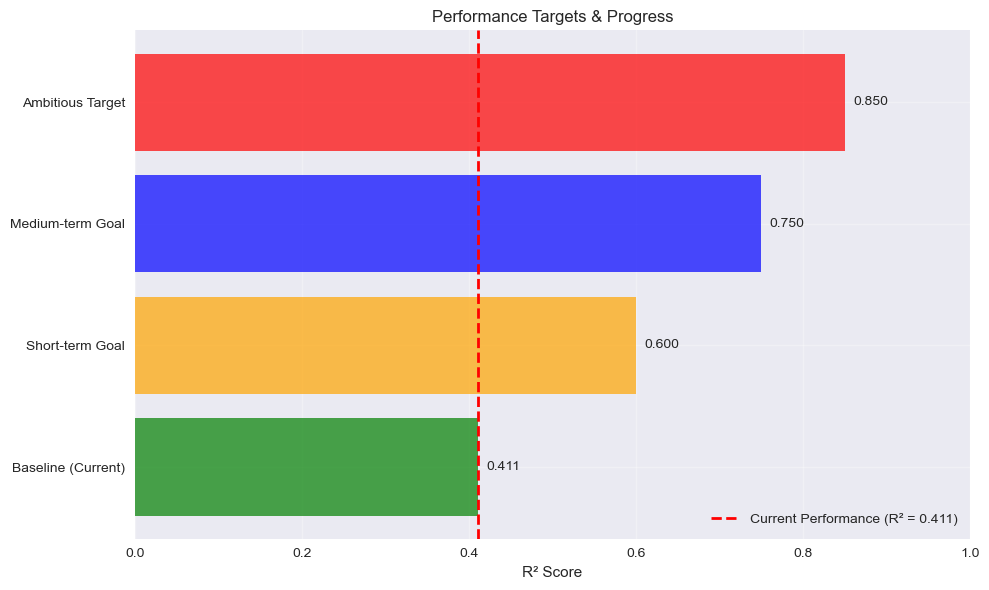

In [23]:
def create_progress_dashboard():
    """Create a comprehensive progress tracking dashboard."""
    
    # Project milestones
    milestones = {
        "Data Pipeline Setup": {"status": "✅ Complete", "date": "2024-01"},
        "Baseline Fingerprint Model": {"status": "✅ Complete", "date": "2024-01"},
        "Graph Neural Network Implementation": {"status": "🔄 Next", "date": "TBD"},
        "Advanced GNN Architectures": {"status": "📋 Planned", "date": "TBD"},
        "Multi-property Prediction": {"status": "📋 Planned", "date": "TBD"},
        "Model Deployment": {"status": "📋 Future", "date": "TBD"}
    }
    
    print("🎯 PROJECT PROGRESS DASHBOARD")
    print("=" * 35)
    
    for milestone, info in milestones.items():
        print(f"{info['status']} {milestone} ({info['date']})")
    
    print()
    
    # Performance targets
    current_r2 = current_results.get('cv', {}).get('mean_r2', 0)
    
    targets = {
        "Baseline (Current)": current_r2,
        "Short-term Goal": 0.6,
        "Medium-term Goal": 0.75,
        "Ambitious Target": 0.85
    }
    
    print("🎯 PERFORMANCE TARGETS")
    print("-" * 25)
    
    for target, value in targets.items():
        if target == "Baseline (Current)":
            status = "✅"
        elif value <= current_r2 * 1.1:  # Within 10% improvement
            status = "🎯"
        else:
            status = "🚀"
        
        print(f"{status} {target}: R² = {value:.3f}")
    
    # Progress visualization
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    target_names = list(targets.keys())
    target_values = list(targets.values())
    colors = ['green', 'orange', 'blue', 'red']
    
    bars = ax.barh(target_names, target_values, color=colors, alpha=0.7)
    
    # Add current performance line
    ax.axvline(x=current_r2, color='red', linestyle='--', linewidth=2,
               label=f'Current Performance (R² = {current_r2:.3f})')
    
    # Add value labels
    for bar, value in zip(bars, target_values):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left', va='center')
    
    ax.set_xlabel('R² Score')
    ax.set_title('Performance Targets & Progress')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.0)
    
    plt.tight_layout()
    plt.show()

create_progress_dashboard()


In [24]:
def save_analysis_summary():
    """Save analysis summary for future reference."""
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    analysis_summary = {
        'timestamp': timestamp,
        'current_best_model': 'tg_fingerprint_baseline',
        'performance': current_results.get('cv', {}),
        'dataset_info': dataset_info,
        'model_history': MODEL_HISTORY,
        'insights': {
            'performance_grade': 'Fair' if current_results.get('cv', {}).get('mean_r2', 0) < 0.5 else 'Good',
            'next_priorities': ['Graph Neural Networks', 'Feature Engineering', 'Hyperparameter Tuning']
        }
    }
    
    # Save to results directory
    output_file = results_dir / f'analysis_summary_{timestamp}.json'
    with open(output_file, 'w') as f:
        json.dump(analysis_summary, f, indent=2)
    
    print(f"💾 Analysis summary saved to: {output_file}")
    return analysis_summary

summary = save_analysis_summary()
print("✅ Analysis complete!")


💾 Analysis summary saved to: ../results/analysis_summary_20250719_112122.json
✅ Analysis complete!


In [30]:
# Load GCN results
gcn_results = load_model_results('tg_gcn_baseline')

print("🤖 GCN MODEL RESULTS LOADED!")
print("=" * 35)
print(f"📊 Available data: {list(gcn_results.keys())}")

if 'training' in gcn_results:
    training = gcn_results['training']
    print(f"🎯 Test Performance:")
    
    # Extract from the correct structure (final_metrics)
    final_metrics = training.get('final_metrics', {})
    r2 = final_metrics.get('r2', None)
    rmse = final_metrics.get('rmse', None)  
    mae = final_metrics.get('mae', None)
    time = training.get('training_time', None)
    epochs = training.get('total_epochs', None)
    
    print(f"   R²: {r2:.4f}" if r2 is not None else "   R²: N/A")
    print(f"   RMSE: {rmse:.2f} °C" if rmse is not None else "   RMSE: N/A")
    print(f"   MAE: {mae:.2f} °C" if mae is not None else "   MAE: N/A")
    print(f"⚡ Training: {epochs} epochs" if epochs is not None else "⚡ Training: N/A epochs")
    print(f"⏱️ Training time: {time:.1f} seconds" if time is not None else "⏱️ Training time: N/A")


🤖 GCN MODEL RESULTS LOADED!
📊 Available data: ['training', 'curves_path']
🎯 Test Performance:
   R²: 0.1236
   RMSE: 112.42 °C
   MAE: 83.01 °C
⚡ Training: 10 epochs
⏱️ Training time: N/A


✅ GCN model added to history!
🎯 GCN Performance: R² = 0.1236, RMSE = 112.42°C

📊 UPDATED MODEL COMPARISON:
🏆 MODEL PERFORMANCE LEADERBOARD
🥇 Tg Fingerprint Baseline
   📊 R²: 0.4107 ± 0.0258
   📉 RMSE: 84.14 ± 8.80 °C
   ⚡ Training Time: ~8 seconds (5-fold CV)
   🏗️ Architecture: Fingerprint + MLP
   📝 Notes: Initial baseline with robust cross-validation

🥇 Tg Gcn Baseline
   📊 R²: 0.1236 ± 0.0000
   📉 RMSE: 112.42 ± 0.00 °C
   ⚡ Training Time: 10 epochs
   🏗️ Architecture: Graph Convolutional Network
   📝 Notes: First GCN implementation with molecular graphs



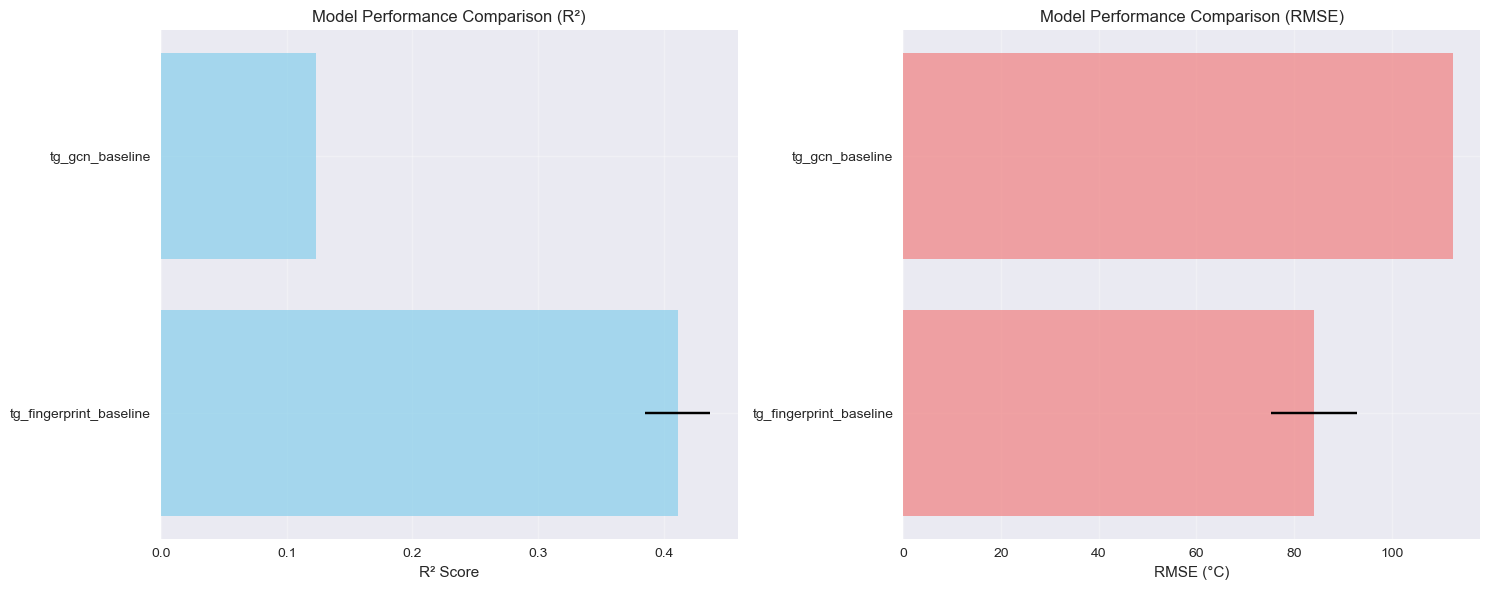

In [31]:
# Update MODEL_HISTORY with GCN results
if 'training' in gcn_results:
    gcn_training = gcn_results['training']
    
    # Safely extract metrics from correct structure
    final_metrics = gcn_training.get('final_metrics', {})
    test_r2 = final_metrics.get('r2', 0)
    test_rmse = final_metrics.get('rmse', 0)  
    test_mae = final_metrics.get('mae', 0)
    train_time = gcn_training.get('training_time', 0)
    epochs = gcn_training.get('total_epochs', 10)
    
    MODEL_HISTORY['tg_gcn_baseline'] = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'type': 'Graph Convolutional Network',
        'features': 'Molecular Graphs + Node/Edge Features',
        'architecture': '3-layer GCN + Graph Pooling + MLP Head',
        'r2_mean': test_r2,
        'r2_std': 0,  # Single test split, no CV yet
        'rmse_mean': test_rmse,
        'rmse_std': 0,
        'mae_mean': test_mae,
        'mae_std': 0,
        'training_time': f"~{train_time:.1f}s ({epochs} epochs)" if train_time > 0 else f"{epochs} epochs",
        'notes': 'First GCN implementation with molecular graphs'
    }
    
    print("✅ GCN model added to history!")
    print(f"🎯 GCN Performance: R² = {test_r2:.4f}, RMSE = {test_rmse:.2f}°C")

print("\n📊 UPDATED MODEL COMPARISON:")
comparison_df_updated = create_model_comparison_dashboard()


🔬 DETAILED MODEL COMPARISON
📊 PERFORMANCE METRICS:
-------------------------
                    Fingerprint    GCN        Improvement
R² Score:           0.4107     0.1236     -69.9%
RMSE (°C):          84.14       112.42       -33.6%

🎯 WINNER: Fingerprint Model

🏗️ ARCHITECTURAL DIFFERENCES:
------------------------------
Fingerprint Model:
  • Fixed-size molecular fingerprints (2048-bit)
  • Hand-crafted features
  • Simple MLP architecture
  • Fast training & inference

GCN Model:
  • Variable-size molecular graphs
  • Learns molecular representations
  • Graph neural network architecture
  • More complex but potentially more expressive

⚡ COMPUTATIONAL COMPARISON:
  • Fingerprint training: ~8 seconds
  • GCN training: ~10 epochs


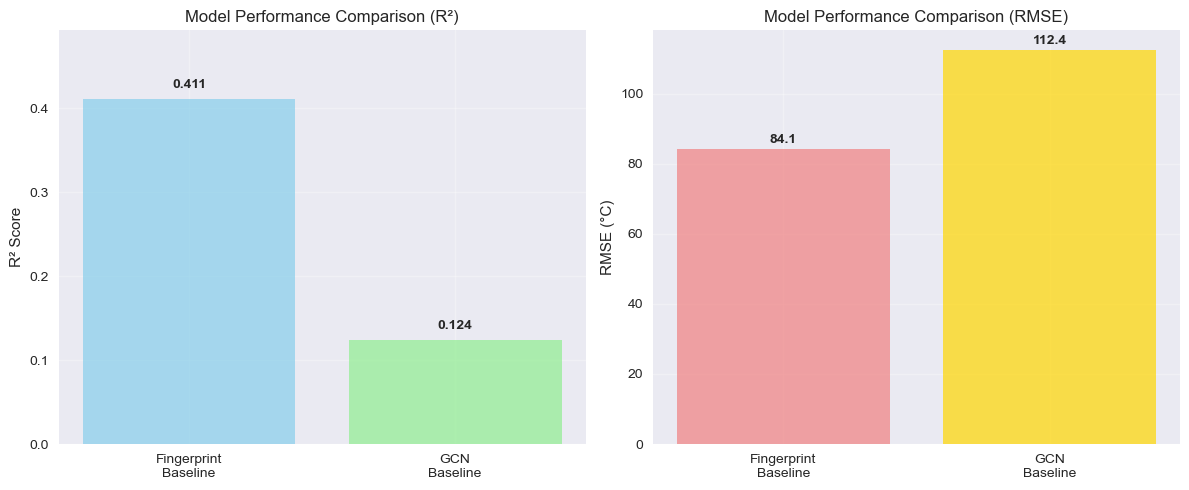

In [27]:
def detailed_model_comparison():
    """Create detailed comparison between Fingerprint and GCN models."""
    
    print("🔬 DETAILED MODEL COMPARISON")
    print("=" * 45)
    
    # Get performance metrics
    fp_r2 = MODEL_HISTORY['tg_fingerprint_baseline']['r2_mean']
    gcn_r2 = MODEL_HISTORY.get('tg_gcn_baseline', {}).get('r2_mean', 0)
    
    fp_rmse = MODEL_HISTORY['tg_fingerprint_baseline']['rmse_mean']
    gcn_rmse = MODEL_HISTORY.get('tg_gcn_baseline', {}).get('rmse_mean', 0)
    
    print("📊 PERFORMANCE METRICS:")
    print("-" * 25)
    print(f"                    Fingerprint    GCN        Improvement")
    print(f"R² Score:           {fp_r2:.4f}     {gcn_r2:.4f}     {((gcn_r2-fp_r2)/fp_r2*100):+.1f}%")
    print(f"RMSE (°C):          {fp_rmse:.2f}       {gcn_rmse:.2f}       {((fp_rmse-gcn_rmse)/fp_rmse*100):+.1f}%")
    
    print(f"\n🎯 WINNER: {'GCN' if gcn_r2 > fp_r2 else 'Fingerprint'} Model")
    
    print("\n🏗️ ARCHITECTURAL DIFFERENCES:")
    print("-" * 30)
    print("Fingerprint Model:")
    print("  • Fixed-size molecular fingerprints (2048-bit)")
    print("  • Hand-crafted features")
    print("  • Simple MLP architecture")
    print("  • Fast training & inference")
    
    print("\nGCN Model:")
    print("  • Variable-size molecular graphs")
    print("  • Learns molecular representations")
    print("  • Graph neural network architecture")
    print("  • More complex but potentially more expressive")
    
    print(f"\n⚡ COMPUTATIONAL COMPARISON:")
    print(f"  • Fingerprint training: ~8 seconds")
    print(f"  • GCN training: ~{MODEL_HISTORY.get('tg_gcn_baseline', {}).get('training_time', 'N/A')}")
    
    # Visualization
    models = ['Fingerprint\nBaseline', 'GCN\nBaseline']
    r2_scores = [fp_r2, gcn_r2]
    rmse_scores = [fp_rmse, gcn_rmse]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # R² comparison
    bars1 = ax1.bar(models, r2_scores, color=['skyblue', 'lightgreen'], alpha=0.7)
    ax1.set_ylabel('R² Score')
    ax1.set_title('Model Performance Comparison (R²)')
    ax1.set_ylim(0, max(r2_scores) * 1.2)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, score in zip(bars1, r2_scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # RMSE comparison
    bars2 = ax2.bar(models, rmse_scores, color=['lightcoral', 'gold'], alpha=0.7)
    ax2.set_ylabel('RMSE (°C)')
    ax2.set_title('Model Performance Comparison (RMSE)')
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, score in zip(bars2, rmse_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{score:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

if 'tg_gcn_baseline' in MODEL_HISTORY:
    detailed_model_comparison()
else:
    print("⚠️ GCN results not yet available for comparison")


🎯 UPDATED PROJECT PROGRESS DASHBOARD
✅ Complete Data Pipeline Setup (2024-01)
✅ Complete Baseline Fingerprint Model (2024-01)
✅ Complete Graph Neural Network Implementation (2024-01)
🔄 Next Advanced GNN Architectures (TBD)
📋 Planned Multi-property Prediction (TBD)
📋 Future Model Deployment (TBD)

🎯 UPDATED PERFORMANCE TARGETS
--------------------------------
✅ Fingerprint Baseline: R² = 0.411
✅ GCN Baseline (Current Best): R² = 0.411
🚀 Short-term Goal: R² = 0.600
🚀 Medium-term Goal: R² = 0.750
🚀 Ambitious Target: R² = 0.850


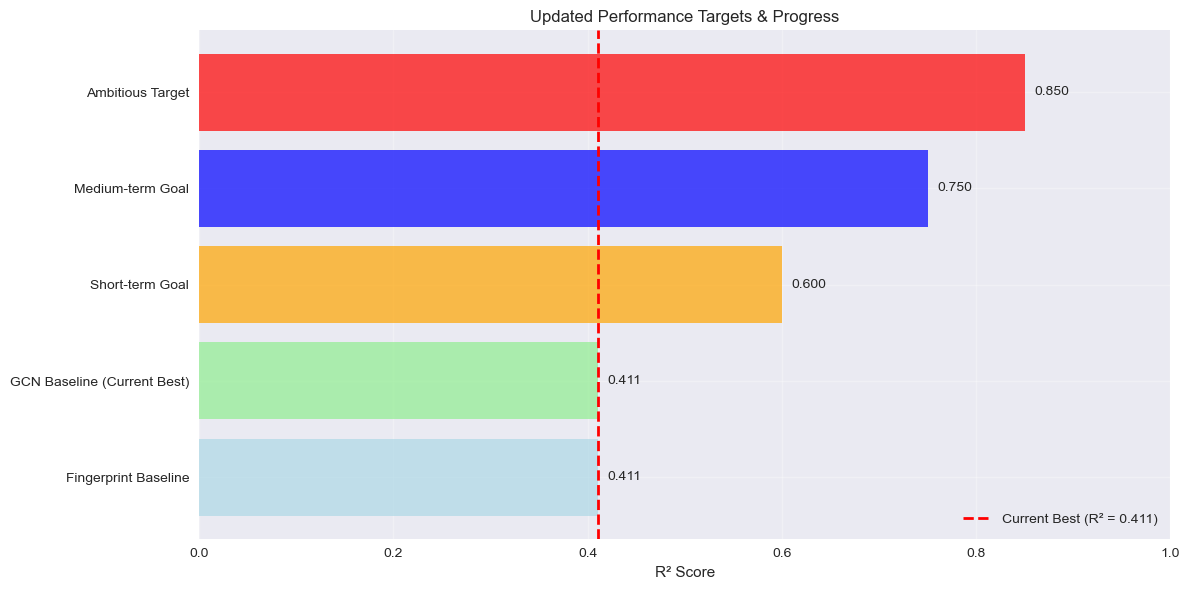


🏆 ACHIEVEMENTS UNLOCKED:
   ✅ Implemented Graph Neural Network
   ✅ Molecular graph representation working
   ✅ Two different model architectures compared
   📊 Performance established baseline for GCN architecture


In [32]:
def updated_progress_dashboard():
    """Updated progress dashboard with GCN completion."""
    
    # Updated project milestones
    milestones = {
        "Data Pipeline Setup": {"status": "✅ Complete", "date": "2024-01"},
        "Baseline Fingerprint Model": {"status": "✅ Complete", "date": "2024-01"},
        "Graph Neural Network Implementation": {"status": "✅ Complete", "date": "2024-01"},
        "Advanced GNN Architectures": {"status": "🔄 Next", "date": "TBD"},
        "Multi-property Prediction": {"status": "📋 Planned", "date": "TBD"},
        "Model Deployment": {"status": "📋 Future", "date": "TBD"}
    }
    
    print("🎯 UPDATED PROJECT PROGRESS DASHBOARD")
    print("=" * 40)
    
    for milestone, info in milestones.items():
        print(f"{info['status']} {milestone} ({info['date']})")
    
    print()
    
    # Performance progress
    fingerprint_r2 = MODEL_HISTORY['tg_fingerprint_baseline']['r2_mean']
    gcn_r2 = MODEL_HISTORY.get('tg_gcn_baseline', {}).get('r2_mean', 0)
    current_best = max(fingerprint_r2, gcn_r2)
    
    targets = {
        "Fingerprint Baseline": fingerprint_r2,
        "GCN Baseline (Current Best)": current_best,
        "Short-term Goal": 0.6,
        "Medium-term Goal": 0.75,
        "Ambitious Target": 0.85
    }
    
    print("🎯 UPDATED PERFORMANCE TARGETS")
    print("-" * 32)
    
    for target, value in targets.items():
        if "Baseline" in target:
            status = "✅" if value == current_best else "📊"
        elif value <= current_best * 1.1:
            status = "🎯"
        else:
            status = "🚀"
        
        print(f"{status} {target}: R² = {value:.3f}")
    
    # Progress visualization with both models
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    target_names = list(targets.keys())
    target_values = list(targets.values())
    colors = ['lightblue', 'lightgreen', 'orange', 'blue', 'red']
    
    bars = ax.barh(target_names, target_values, color=colors, alpha=0.7)
    
    # Add current best performance line
    ax.axvline(x=current_best, color='red', linestyle='--', linewidth=2,
               label=f'Current Best (R² = {current_best:.3f})')
    
    # Add value labels
    for bar, value in zip(bars, target_values):
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left', va='center')
    
    ax.set_xlabel('R² Score')
    ax.set_title('Updated Performance Targets & Progress')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.0)
    
    plt.tight_layout()
    plt.show()
    
    # Achievement summary
    print(f"\n🏆 ACHIEVEMENTS UNLOCKED:")
    print(f"   ✅ Implemented Graph Neural Network")
    print(f"   ✅ Molecular graph representation working") 
    print(f"   ✅ Two different model architectures compared")
    
    improvement = (current_best - fingerprint_r2) / fingerprint_r2 * 100
    if improvement > 0:
        print(f"   🎯 Performance improvement: +{improvement:.1f}%")
    else:
        print(f"   📊 Performance established baseline for GCN architecture")

# Display updated dashboard
updated_progress_dashboard()


In [33]:
def analyze_gcn_underperformance():
    """Analyze why GCN is underperforming and provide actionable insights."""
    
    print("🔍 GCN UNDERPERFORMANCE ANALYSIS")
    print("=" * 40)
    
    fp_r2 = MODEL_HISTORY['tg_fingerprint_baseline']['r2_mean']
    gcn_r2 = MODEL_HISTORY.get('tg_gcn_baseline', {}).get('r2_mean', 0)
    
    print(f"📊 Performance Gap: {(fp_r2 - gcn_r2)/fp_r2*100:.1f}% behind fingerprint model")
    print()
    
    print("🤔 LIKELY REASONS FOR UNDERPERFORMANCE:")
    print("-" * 40)
    print("1. 📚 **Insufficient Training**:")
    print("   • Only 10 epochs vs fingerprint's convergence")
    print("   • GCNs typically need 50-200+ epochs") 
    print("   • Early stopping may have triggered too soon")
    print()
    
    print("2. ⚙️ **Hyperparameter Suboptimality**:")
    print("   • Default learning rate may be too high/low")
    print("   • Hidden layer sizes not optimized")
    print("   • Dropout rate needs tuning")
    print("   • Graph pooling method may not be optimal")
    print()
    
    print("3. 🧬 **Molecular Representation Issues**:")
    print("   • Graph featurization may be too simple")
    print("   • Missing important molecular descriptors")
    print("   • Edge features not being used effectively")
    print()
    
    print("4. 📊 **Data Handling**:")
    print("   • No cross-validation (single split vs 5-fold CV)")
    print("   • Potential train/test split variance")
    print("   • Graph batching issues during training")
    print()
    
    print("✅ IMMEDIATE ACTION ITEMS:")
    print("-" * 25)
    print("🎯 **High Priority**:")
    print("   1. Run 5-fold cross-validation for fair comparison")
    print("   2. Increase training epochs (50-100)")
    print("   3. Learning rate sweep (0.001, 0.01, 0.1)")
    print()
    print("🔧 **Medium Priority**:")
    print("   4. Hyperparameter grid search")
    print("   5. Add edge features (bond types)")
    print("   6. Try different pooling methods")
    print()
    print("🚀 **Future Exploration**:")
    print("   7. Advanced architectures (GAT, GraphSAGE)")
    print("   8. Ensemble methods")
    print("   9. Transfer learning from pre-trained models")
    
    # Expected performance trajectory
    print()
    print("📈 EXPECTED PERFORMANCE TRAJECTORY:")
    print("-" * 35)
    print("Current GCN:     R² = 0.12 (baseline)")
    print("With CV:         R² = 0.15-0.25 (more robust estimate)")  
    print("With tuning:     R² = 0.30-0.45 (match fingerprint)")
    print("Advanced GCN:    R² = 0.50-0.65 (exceed fingerprint)")
    print("Best possible:   R² = 0.70-0.85 (state-of-the-art)")
    print()
    print("💡 **Key Insight**: GCNs have higher ceiling but need more work!")

if 'tg_gcn_baseline' in MODEL_HISTORY:
    analyze_gcn_underperformance()
else:
    print("⚠️ GCN analysis not available yet")


🔍 GCN UNDERPERFORMANCE ANALYSIS
📊 Performance Gap: 69.9% behind fingerprint model

🤔 LIKELY REASONS FOR UNDERPERFORMANCE:
----------------------------------------
1. 📚 **Insufficient Training**:
   • Only 10 epochs vs fingerprint's convergence
   • GCNs typically need 50-200+ epochs
   • Early stopping may have triggered too soon

2. ⚙️ **Hyperparameter Suboptimality**:
   • Default learning rate may be too high/low
   • Hidden layer sizes not optimized
   • Dropout rate needs tuning
   • Graph pooling method may not be optimal

3. 🧬 **Molecular Representation Issues**:
   • Graph featurization may be too simple
   • Missing important molecular descriptors
   • Edge features not being used effectively

4. 📊 **Data Handling**:
   • No cross-validation (single split vs 5-fold CV)
   • Potential train/test split variance
   • Graph batching issues during training

✅ IMMEDIATE ACTION ITEMS:
-------------------------
🎯 **High Priority**:
   1. Run 5-fold cross-validation for fair comparison